
# Baseline notebook — ESG_Overall prediction (production-ready)

**Purpose:** Predict `ESG_Overall` for each company-year using the dataset at `/mnt/data/company_esg_financial_dataset.csv`.

This notebook follows industry best practices:
- safe data loading (`parse_dates`/`dtype`)
- no data leakage: preprocessing fitted on training set only using `Pipeline` and `ColumnTransformer`
- reproducible training (random_state)
- train/test split by YEAR (train <= 2021, test > 2021)
- model artifact saving (joblib) and feature list saving (JSON)

Run every cell sequentially. If you need GPU or extra libraries (XGBoost/LightGBM/SHAP/MLflow), install them in your environment.


In [28]:

# Setup: imports and config
import warnings, os, json
from pathlib import Path
import numpy as np, pandas as pd
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LinearRegression, Ridge
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import joblib
import matplotlib.pyplot as plt

warnings.filterwarnings('ignore')

# Paths
DATA_PATH = Path('../data/company_esg_financial_dataset.csv')
OUT_DIR = Path('data/esg_artifacts')
OUT_DIR.mkdir(exist_ok=True, parents=True)

# Config
TARGET = 'ESG_Overall'   # target column
YEAR_COL = 'Year'        # year column present in dataset
TRAIN_YEAR_CUTOFF = 2021 # train: <= 2021 ; test: > 2021
RANDOM_STATE = 42


In [29]:

# Load dataset with lightweight validation
assert DATA_PATH.exists(), f"Data file not found at {DATA_PATH}. Upload it to /mnt/data/ and rerun."

# Read CSV. Year is an integer column — we'll parse into datetime for clarity
df = pd.read_csv(DATA_PATH, dtype={ 'CompanyID': int }, low_memory=False)
print('Loaded rows:', len(df), 'columns:', len(df.columns))
print('Columns:', df.columns.tolist())

# Ensure YEAR column exists
if YEAR_COL not in df.columns:
    raise ValueError(f"Year column '{YEAR_COL}' not found. Detected columns: {df.columns.tolist()}")

# Convert Year to datetime (end-of-year) and keep numeric year as int
df[YEAR_COL] = df[YEAR_COL].astype(int)
df['date'] = pd.to_datetime(df[YEAR_COL].astype(str) + '-12-31')

# Basic checks
if TARGET not in df.columns:
    raise ValueError(f"Target column '{TARGET}' not found in dataset. Columns: {df.columns.tolist()}")
print('\nSample:') 
display(df.head(3).T)
print('\nValue counts for Year:') 
print(df[YEAR_COL].value_counts().sort_index())


Loaded rows: 11000 columns: 16
Columns: ['CompanyID', 'CompanyName', 'Industry', 'Region', 'Year', 'Revenue', 'ProfitMargin', 'MarketCap', 'GrowthRate', 'ESG_Overall', 'ESG_Environmental', 'ESG_Social', 'ESG_Governance', 'CarbonEmissions', 'WaterUsage', 'EnergyConsumption']

Sample:


,0,1,2
CompanyID,1,1,1
CompanyName,Company_1,Company_1,Company_1
Industry,Retail,Retail,Retail
Region,Latin America,Latin America,Latin America
Year,2015,2016,2017
Revenue,459.2,473.8,564.9
ProfitMargin,6.0,4.6,5.2
MarketCap,337.5,366.6,313.4
GrowthRate,NaN,3.2,19.2
ESG_Overall,57.0,56.7,56.5



Value counts for Year:
Year
2015    1000
2016    1000
2017    1000
2018    1000
2019    1000
2020    1000
2021    1000
2022    1000
2023    1000
2024    1000
2025    1000
Name: count, dtype: int64


In [30]:

# === Feature selection and basic preprocessing ===

# Drop obvious identifiers from features (but keep CompanyID for grouping if needed)
ID_COLS = ['CompanyID', 'CompanyName'] if 'CompanyName' in df.columns else ['CompanyID']
NON_PREDICTIVE = ID_COLS + ['date', YEAR_COL]

# Create candidate features list: everything except target and non-predictive cols
feature_cols = [c for c in df.columns if c not in NON_PREDICTIVE + [TARGET]]
print('Candidate feature columns count:', len(feature_cols))

# Quick dtype separation
num_cols = df[feature_cols].select_dtypes(include=['int64','float64']).columns.tolist()
cat_cols = df[feature_cols].select_dtypes(include=['object','category']).columns.tolist()
print('Numerical cols:', len(num_cols), 'Categorical cols:', len(cat_cols))
print('Sample numerical:', num_cols[:10])
print('Sample categorical:', cat_cols[:10])

# Imputation and transformers
numeric_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler())
])

categorical_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='constant', fill_value='__missing__')),
    ('onehot', OneHotEncoder(handle_unknown='ignore', sparse_output=False))
])

preprocessor = ColumnTransformer(transformers=[
    ('num', numeric_transformer, num_cols),
    ('cat', categorical_transformer, cat_cols)
], remainder='drop', verbose_feature_names_out=False)

# Build a pipeline with a placeholder estimator (we'll swap estimators later)
baseline_pipeline = Pipeline(steps=[
    ('preproc', preprocessor),
    ('model', LinearRegression())
])

print('\nPipeline constructed. To avoid leakage, the preprocessor will be fit only on training data.')


Candidate feature columns count: 12
Numerical cols: 10 Categorical cols: 2
Sample numerical: ['Revenue', 'ProfitMargin', 'MarketCap', 'GrowthRate', 'ESG_Environmental', 'ESG_Social', 'ESG_Governance', 'CarbonEmissions', 'WaterUsage', 'EnergyConsumption']
Sample categorical: ['Industry', 'Region']

Pipeline constructed. To avoid leakage, the preprocessor will be fit only on training data.


In [31]:

# === Train / Test split by YEAR cut-off (temporal split) ===

train_df = df[df[YEAR_COL] <= TRAIN_YEAR_CUTOFF].copy()
test_df = df[df[YEAR_COL] > TRAIN_YEAR_CUTOFF].copy()

print(f"Train rows: {len(train_df)}, Test rows: {len(test_df)}. Train years: {sorted(train_df[YEAR_COL].unique())}")

X_train = train_df[feature_cols]
y_train = train_df[TARGET].astype(float)
X_test = test_df[feature_cols]
y_test = test_df[TARGET].astype(float)

# Sanity checks
assert len(X_train) > 0 and len(X_test) > 0, 'Empty train or test after split. Adjust TRAIN_YEAR_CUTOFF.'


Train rows: 7000, Test rows: 4000. Train years: [np.int64(2015), np.int64(2016), np.int64(2017), np.int64(2018), np.int64(2019), np.int64(2020), np.int64(2021)]


In [32]:
# Save preprocessed train/test datasets for reuse in advanced modeling
from sklearn.compose import ColumnTransformer

train_proc = pd.DataFrame(preprocessor.fit_transform(X_train), columns=preprocessor.get_feature_names_out())
train_proc[TARGET] = y_train.values
test_proc = pd.DataFrame(preprocessor.transform(X_test), columns=preprocessor.get_feature_names_out())
test_proc[TARGET] = y_test.values

train_proc.to_csv(OUT_DIR / 'train_processed.csv', index=False)
test_proc.to_csv(OUT_DIR / 'test_processed.csv', index=False)

print('Saved processed splits to:', OUT_DIR)


Saved processed splits to: data\esg_artifacts


In [33]:

# === Train baseline models and evaluate ===

def evaluate_model(model, X_test, y_test):
    y_pred = model.predict(X_test)
    mse = mean_squared_error(y_test, y_pred)
    rmse = np.sqrt(mse)
    mae = mean_absolute_error(y_test, y_pred)
    r2 = r2_score(y_test, y_pred)
    return {'rmse': rmse, 'mae': mae, 'r2': r2, 'y_pred': y_pred}

models = {
    'LinearRegression': LinearRegression(),
    'Ridge': Ridge(alpha=1.0, random_state=RANDOM_STATE),
    'RandomForest': RandomForestRegressor(n_estimators=200, random_state=RANDOM_STATE, n_jobs=-1)
}

results = []
fitted_models = {}

for name, estimator in models.items():
    print('\nTraining', name)
    # set estimator into pipeline
    pipeline = Pipeline(steps=[('preproc', preprocessor), ('model', estimator)])
    pipeline.fit(X_train, y_train)
    fitted_models[name] = pipeline
    res = evaluate_model(pipeline, X_test, y_test)
    print(f"{name} -> RMSE: {res['rmse']:.4f}, MAE: {res['mae']:.4f}, R2: {res['r2']:.4f}")
    results.append({'model': name, 'rmse': res['rmse'], 'mae': res['mae'], 'r2': res['r2']})



Training LinearRegression
LinearRegression -> RMSE: 0.0329, MAE: 0.0258, R2: 1.0000

Training Ridge
Ridge -> RMSE: 0.0329, MAE: 0.0262, R2: 1.0000

Training RandomForest
RandomForest -> RMSE: 1.3221, MAE: 0.9627, R2: 0.9929


In [34]:

# === Results summary and saving artifacts ===
results_df = pd.DataFrame(results).sort_values('rmse').reset_index(drop=True)
display(results_df)

# Save the best model pipeline
best_model_name = results_df.loc[0, 'model']
best_pipeline = fitted_models[best_model_name]
model_path = OUT_DIR / f"esg_pipeline_{best_model_name}.joblib"
joblib.dump(best_pipeline, model_path)
print('Saved best pipeline to', model_path)

# Save metadata (feature names and config)
metadata = {
    'target': TARGET,
    'features': feature_cols,
    'num_cols': num_cols,
    'cat_cols': cat_cols,
    'train_years': [int(x) for x in sorted(train_df[YEAR_COL].unique())],
    'test_years': [int(x) for x in sorted(test_df[YEAR_COL].unique())],
    'best_model': best_model_name
}
meta_path = OUT_DIR / 'metadata.json'
with open(meta_path, 'w') as f:
    json.dump(metadata, f, indent=2)
print(f"✅ Saved metadata: {meta_path}")

# Save results table separately for dashboards / reports
results_csv_path = OUT_DIR / 'results_summary.csv'
results_df.to_csv(results_csv_path, index=False)
print(f"📊 Saved detailed results: {results_csv_path}")

,model,rmse,mae,r2
0,LinearRegression,0.032861,0.025836,0.999996
1,Ridge,0.032931,0.026158,0.999996
2,RandomForest,1.322113,0.962686,0.992946


Saved best pipeline to data\esg_artifacts\esg_pipeline_LinearRegression.joblib
✅ Saved metadata: data\esg_artifacts\metadata.json
📊 Saved detailed results: data\esg_artifacts\results_summary.csv


,feature,importance
6,ESG_Governance,0.406830
4,ESG_Environmental,0.341178
5,ESG_Social,0.244713
0,Revenue,0.001162
1,ProfitMargin,0.000989
8,WaterUsage,0.000954
9,EnergyConsumption,0.000749
2,MarketCap,0.000719
7,CarbonEmissions,0.000705
3,GrowthRate,0.000577


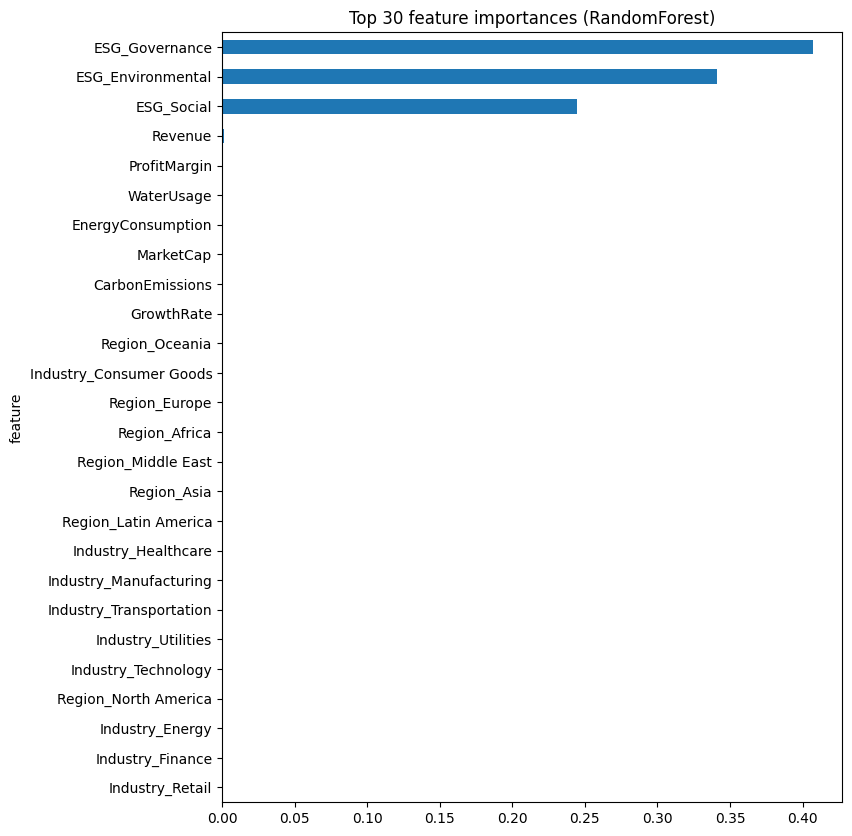

In [35]:

# === Feature importances (for tree-based models) ===
import numpy as np
if 'RandomForest' in fitted_models:
    rf = fitted_models['RandomForest']
    # extract feature names after preprocessing
    # preprocessor has transformers that expand categorical columns; get_feature_names_out is supported
    try:
        feature_names = rf.named_steps['preproc'].get_feature_names_out()
    except Exception:
        # fallback: construct names approximate
        num_names = num_cols
        cat_names = rf.named_steps['preproc'].transformers_[1][1].named_steps['onehot'].get_feature_names_out(cat_cols).tolist() if len(cat_cols)>0 else []
        feature_names = list(num_names) + list(cat_names)

    importances = rf.named_steps['model'].feature_importances_
    fi = pd.DataFrame({'feature': feature_names, 'importance': importances}).sort_values('importance', ascending=False).head(30)
    display(fi)
    # simple horizontal bar
    fi.set_index('feature')['importance'].sort_values().plot(kind='barh', figsize=(8,10))
    plt.title('Top 30 feature importances (RandomForest)')
    plt.show()
else:
    print('RandomForest model not trained; skipping feature importance.')


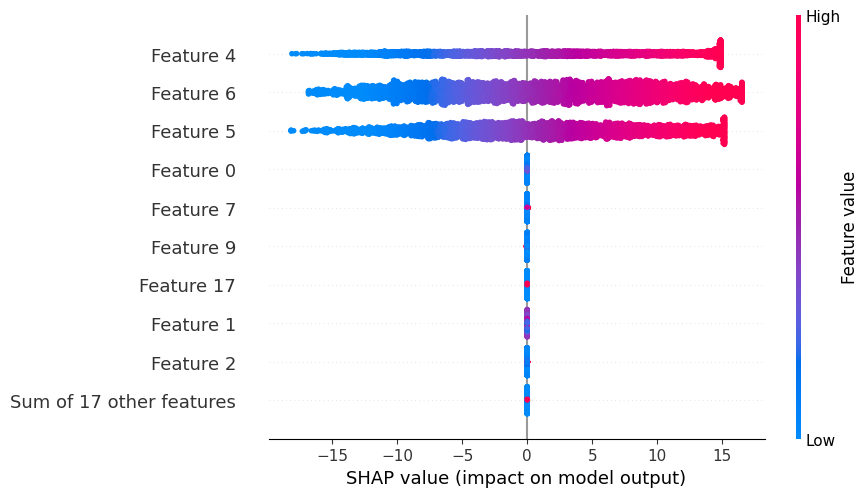

In [36]:

# === SHAP explainability placeholder ===
# If you want SHAP, install shap and run explanation on the best model.
# Example (uncomment & run after installing shap):
#
import shap
explainer = shap.Explainer(best_pipeline.named_steps['model'], best_pipeline.named_steps['preproc'].transform(X_train))
shap_values = explainer(best_pipeline.named_steps['preproc'].transform(X_test))
shap.plots.beeswarm(shap_values)

#print('To run SHAP: pip install shap; then create explainer with preprocessed data as shown in comments.')


In [37]:
print('Notebook complete. Review results_df above and the saved pipeline + metadata in', OUT_DIR)

Notebook complete. Review results_df above and the saved pipeline + metadata in data\esg_artifacts
